# Rowan product conformer analysis

Built with [Vicena](https://vicena.ai). This notebook analyzes a saved Rowan result and does not submit or resubmit any paid workflow.

Scientific boundary: the completed workflow prepares a cyclohexene product conformer. It does not validate the Diels-Alder reaction pathway, transition state, frequencies, activation thermochemistry, or IRC connection.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
raw_path = ROOT / "results/example/rowan/product_conformer_raw.json"
prov_path = ROOT / "results/example/rowan/workflow_provenance.json"
summary_path = ROOT / "results/example/rowan/summary.csv"
raw = json.loads(raw_path.read_text())
provenance = json.loads(prov_path.read_text())
summary = pd.read_csv(summary_path)

print("Workflow UUID:", provenance["workflow_uuid"])
print("Status:", provenance["status"])
print("Rowan credits charged:", provenance["budget"]["rowan_credits_charged"])
print("Estimated Vicena credits charged:", provenance["budget"]["estimated_vicena_credits_charged"])
print("Conformers returned:", len(raw["energies"]))
print("Provider path energies[0]:", raw["energies"][0])
print("Returned canonical SMILES:", raw["initial_molecule"].get("smiles"))
display(summary)

Workflow UUID: 3d530210-368d-4296-9460-94b383d7295a
Status: completed-ok
Rowan credits charged: 0.37
Estimated Vicena credits charged: 37
Conformers returned: 1
Provider path energies[0]: -234.80424401193108
Returned canonical SMILES: C1=CCCCC1


,task_key,name,workflow_type,workflow_uuid,status,max_credits,result_path,failure_log_path,result_error,failure_phase,failure_kind
0,f43370cdba3ac6d039a29b05,Diels-Alder cyclohexene product conformers,conformer_search,3d530210-368d-4296-9460-94b383d7295a,completed-ok,1,/root/sessions/476_open-source-reaction-mechan...,NaN,NaN,NaN,NaN


In [2]:
props = pd.DataFrame(raw["conformer_properties"])
props.index.name = "conformer_index"
display(props)
print("Radius of gyration:", props.loc[0, "radius_of_gyration"])
print("Solvent accessible surface area:", props.loc[0, "solvent_accessible_surface_area"])
print("Polar solvent accessible surface area:", props.loc[0, "polar_solvent_accessible_surface_area"])

,polar_solvent_accessible_surface_area,radius_of_gyration,solvent_accessible_surface_area
conformer_index,,,
0,0.0,1.584,262.643


Radius of gyration: 1.584
Solvent accessible surface area: 262.643
Polar solvent accessible surface area: 0.0


,atom_index,atomic_number,x_A,y_A,z_A
0,1,6,0.707300,-1.288506,-0.294379
1,2,6,1.460863,-0.016555,-0.554189
2,3,6,0.948710,1.200281,-0.317483
3,4,6,-0.443782,1.417963,0.199044
4,5,6,-1.317165,0.163226,0.117397
5,6,6,-0.547639,-1.079332,0.557209
6,7,1,0.430760,-1.729435,-1.259480
7,8,1,1.365143,-2.005307,0.210023
8,9,1,2.469631,-0.107790,-0.949132
9,10,1,1.553147,2.084017,-0.506116


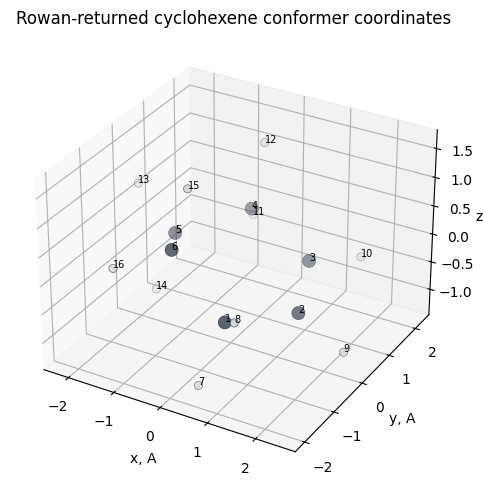

Atom count: 16 Charge: 0 Multiplicity: 1


In [3]:
atoms = raw["initial_molecule"]["atoms"]
coords = pd.DataFrame(
    [{"atom_index": i + 1, "atomic_number": a["atomic_number"], "x_A": a["position"][0], "y_A": a["position"][1], "z_A": a["position"][2]} for i, a in enumerate(atoms)]
)
display(coords)
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
colors = ["#374151" if z == 6 else "#d1d5db" for z in coords.atomic_number]
sizes = [90 if z == 6 else 35 for z in coords.atomic_number]
ax.scatter(coords.x_A, coords.y_A, coords.z_A, c=colors, s=sizes, edgecolors="black", linewidths=0.3)
for _, row in coords.iterrows():
    ax.text(row.x_A, row.y_A, row.z_A, str(int(row.atom_index)), fontsize=7)
ax.set_xlabel("x, A"); ax.set_ylabel("y, A"); ax.set_zlabel("z, A")
ax.set_title("Rowan-returned cyclohexene conformer coordinates")
plt.tight_layout(); plt.show()
print("Atom count:", len(coords), "Charge:", raw["initial_molecule"]["charge"], "Multiplicity:", raw["initial_molecule"]["multiplicity"])

In [4]:
acceptance = provenance["acceptance"]
display(pd.Series(acceptance, name="value").to_frame())
assert acceptance["endpoint_conformer_collected"] is True
assert acceptance["reaction_path_validated"] is False
assert acceptance["transition_state_validated"] is False
assert acceptance["frequencies_validated"] is False
assert acceptance["irc_validated"] is False
print("Conclusion:", acceptance["statement"])
print("Numerical workflow completion is not evidence of a valid reaction mechanism.")

,value
endpoint_conformer_collected,True
reaction_path_validated,False
transition_state_validated,False
frequencies_validated,False
irc_validated,False
statement,This result supports product endpoint preparat...


Conclusion: This result supports product endpoint preparation only.
Numerical workflow completion is not evidence of a valid reaction mechanism.


## Interpretation

The Rowan workflow returned one cyclohexene conformer and a saved provider energy scalar. The repository preserves the raw provider path and value without using it as an activation or reaction energy. No compatible reactant endpoint, transition-state candidate, frequency calculation, thermochemical correction, or IRC was produced by this job.

The next scientifically defensible ladder would require separately authorized budgets for matched endpoint preparation, double-ended TS search, TS optimization, frequency validation, and bidirectional IRC. A TS must be rejected unless it has exactly one relevant imaginary frequency and path evidence connecting the intended endpoint regions.